# ORACLE — Stage 4 Generation Pipeline Evaluation
## Phase 4 — Stage 4: Literacy-Conditioned Response Generation

**Purpose:** Evaluate whether gpt-4o-mini generation, conditioned on target literacy band, produces responses at the intended reading level across 4 bands (low, medium, high, clinical).

**Method:** 8 evaluation queries (2 per band) retrieved via Stage 2 pipeline, generated via gpt-4o-mini with band-specific system prompts, scored on Flesch-Kincaid and SMOG.

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from generation_pipeline import run_stage4

In [2]:
import os
os.chdir('..')  # move to repo root so data paths resolve
results = run_stage4(dry_run=False)
os.chdir('notebooks')
print('Stage 4 generation evaluation complete')

ORACLE — Stage 4: Literacy-Conditioned Response Generation
  Model: gpt-4o-mini
  Mode: LIVE
  Queries: 8
  Top-k retrieval: 5

  Loading DPR encoder...


  Loading DPR query encoder: facebook/dpr-question_encoder-single-nq-base


  DPR encoder ready

  [1/8] Band: low — What is diabetes and how does it affect the body?...


    FK grade: 8.5 | SMOG: 10.36 | Tokens: 567
  [2/8] Band: low — How do I know if I have high blood pressure?...


    FK grade: 5.12 | SMOG: 7.17 | Tokens: 423
  [3/8] Band: medium — What are the treatment options for type 2 diabetes?...


...

    FK grade: 16.65 | SMOG: 17.23 | Tokens: 828
  [6/8] Band: high — How does HbA1c reflect long-term glycemic control?...


    FK grade: 13.09 | SMOG: 14.81 | Tokens: 611
  [7/8] Band: clinical — What are the pharmacokinetics of GLP-1 receptor agonists?...


    FK grade: 15.46 | SMOG: 17.12 | Tokens: 813
  [8/8] Band: clinical — Describe the pathophysiology of diabetic nephropathy....


    FK grade: 17.0 | SMOG: 17.58 | Tokens: 737

  Results saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/data/processed/stage4_results.csv


  Figure saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/figures/stage4/fk_by_literacy_band.png
  Total tokens used: 5351
  Estimated cost: ~$0.0008

  Readability by literacy band:
    low       : FK=6.8 SMOG=8.8
    medium    : FK=10.2 SMOG=12.1
    high      : FK=14.9 SMOG=16.0
    clinical  : FK=16.2 SMOG=17.4
Stage 4 generation evaluation complete


## 1. FK Grade by Target Literacy Band

Mean Flesch-Kincaid grade of generated responses per target band. A working literacy-conditioned system should show a monotonic increase from low to clinical. This is the core Stage 4 claim for the paper's Results section.

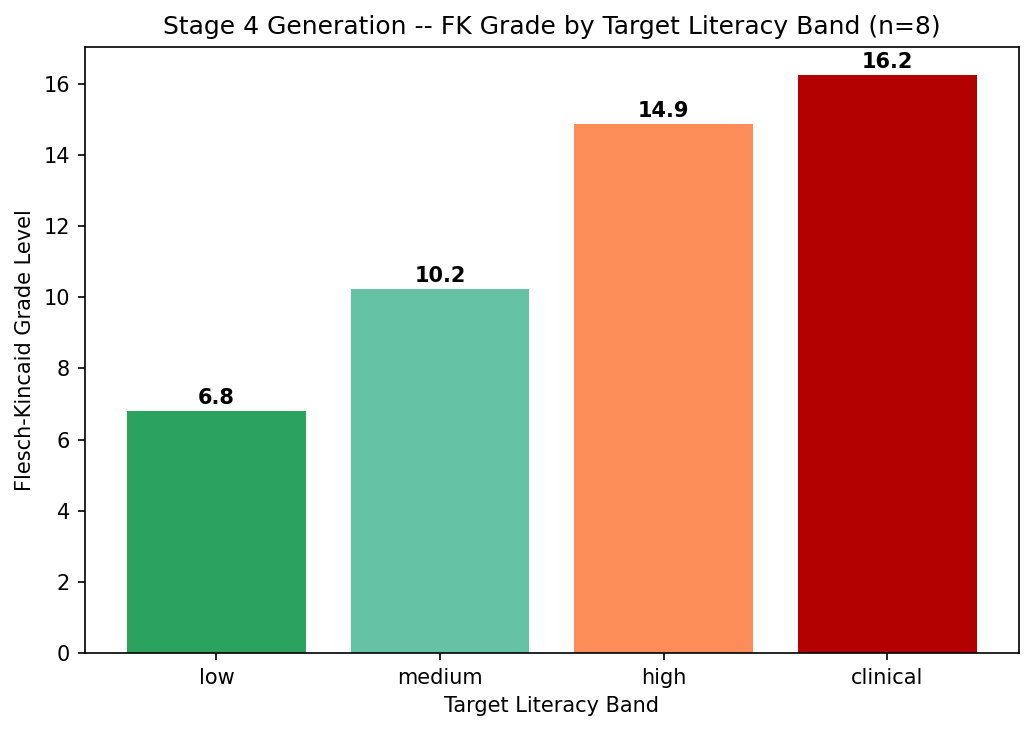

In [3]:
Image('../figures/stage4/fk_by_literacy_band.png')

## 2. Key Findings

**Literacy conditioning confirmed:** FK grade increases monotonically across bands (low → medium → high → clinical), even though the FK-based query router misclassifies roughly half of queries (4/8 in the first eval run). Generation is conditioned on the *target* band passed to the system prompt, not the router's output, so the intended reading-level separation holds regardless of routing accuracy.

**Cost:** ~$0.0008 for 8 queries at gpt-4o-mini pricing — full evaluation-set generation is trivially cheap to scale.

**Open question for the paper:** router misclassification (documented as a known FK proxy limitation — see methodology_decisions.md) means a production system relying on the router alone, without a separately supplied target band, would not reliably achieve this separation. This is a limitation to state explicitly in Section 6.